# Rice Leaf Diseases Dataset | داده بیماری‌های برگ برنج

**English** | **[فارسی](#فارسی)**

---

## English

A curated subset of the rice leaf diseases dataset containing **400 images per class** for three disease categories:
- **Bacterial Blight**
- **Brown Spot**
- **Leaf Smut**

The original dataset was resampled using the provided Python script (`prepare_dataset.py`) to ensure balanced class sizes and avoid overfitting.

### Dataset Structure


## 1. Dataset Sampling and Preparation | آماده‌سازی و نمونه‌برداری از دیتاست

**English:**
In this step, we balance the dataset by randomly sampling a maximum of $400$ images from each class (`Bacterialblight`, `Brownspot`, and `Leafsmut`). This prevents the model from becoming biased towards a specific class with more images. We also use a fixed random seed (`42`) to ensure reproducibility.

**فارسی:**
در این مرحله، برای بالانس کردن (متعادل‌سازی) دیتاست، از هر کلاس حداکثر $400$ تصویر را به صورت تصادفی انتخاب کرده و به یک پوشه جدید منتقل می‌کنیم. این کار باعث می‌شود مدل به سمت کلاسی که دیتای بیشتری دارد سوگیری  پیدا نکند. همچنین برای این‌که نتایج در اجراهای بعدی دقیقاً یکسان باشد، سید رندوم روی $42$ تنظیم شده است.


In [99]:
import os
import random
import shutil
import random
import shutil
from PIL import Image
import hashlib
from torchvision.datasets import ImageFolder
from torchvision.transforms import Compose, Resize, ToTensor, Normalize, RandomHorizontalFlip, RandomVerticalFlip, RandomRotation, ColorJitter
from torch.utils.data import DataLoader
import torch
from StepByStep import StepByStep
from torchvision import datasets, transforms
import torch.nn.functional as F
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt
import copy  


# Define folders paths containing images
base_dir = r"C:\Users\ASUS\Desktop\rice leaf diseases dataset\rice leaf diseases dataset"

folder_paths = {
    'Bacterialblight': os.path.join(base_dir, 'Bacterialblight'),
    'Brownspot': os.path.join(base_dir, 'Brownspot'),
    'Leafsmut': os.path.join(base_dir, 'Leafsmut')
}

# Create main output folder
main_output_folder = os.path.join(base_dir, 'New rice leaf diseases')

random.seed(42)

# Reset output folder to avoid duplicates from previous runs
if os.path.exists(main_output_folder):
    shutil.rmtree(main_output_folder)

os.makedirs(main_output_folder)

# Variable to store total number of extracted images
total_extracted_images = 0

# Iterate over each class folder
for class_name, folder_path in folder_paths.items():

    images = os.listdir(folder_path)
    num_initial_images = len(images)

    print(f"Initial number of images in '{class_name}' folder: {num_initial_images}")

    class_output_folder = os.path.join(main_output_folder, class_name)
    os.makedirs(class_output_folder)

    num_images_to_extract = min(400, num_initial_images)

    selected_images = random.sample(images, num_images_to_extract)

    for image_name in selected_images:
        source_path = os.path.join(folder_path, image_name)
        destination_path = os.path.join(class_output_folder, image_name)
        shutil.copyfile(source_path, destination_path)

    print(f"Extracted {num_images_to_extract} images from '{class_name}' folder.")

    total_extracted_images += num_images_to_extract


print(f"Total number of images extracted in all: {total_extracted_images}")


Initial number of images in 'Bacterialblight' folder: 1604
Extracted 400 images from 'Bacterialblight' folder.
Initial number of images in 'Brownspot' folder: 1620
Extracted 400 images from 'Brownspot' folder.
Initial number of images in 'Leafsmut' folder: 1460
Extracted 400 images from 'Leafsmut' folder.
Total number of images extracted in all: 1200


## 2. Removing Exact Duplicate Images | حذف تصاویر دقیقاً تکراری

**English:**
To ensure data quality and prevent data leakage, it is crucial to remove duplicate images from the dataset. This script reads each image, converts it to RGB, and generates an MD5 hash based on its raw bytes. If an image produces a hash that has already been recorded, it is flagged as a duplicate and permanently removed.

**فارسی:**
برای اطمینان از کیفیت داده‌ها و جلوگیری از نشت داده ، حذف تصاویر تکراری از دیتاست بسیار مهم است. این اسکریپت هر تصویر را می‌خواند، آن را به فرمت آر جی بی تبدیل کرده و یک کد هش  بر اساس بایت‌های آن تولید می‌کند. اگر هش تصویری با هش‌های قبلی برابر باشد، به عنوان تصویر تکراری شناسایی شده و حذف می‌گردد.

**Output | خروجی:**
====================================
Total duplicate images removed: 89
====================================


In [100]:


def find_and_remove_duplicates(root_dir):
    images_dict = {}
    duplicate_count = 0

    classes = ['Bacterialblight', 'Brownspot', 'Leafsmut']

    for cls in classes:
        class_dir = os.path.join(root_dir, cls)

        if not os.path.isdir(class_dir):
            print(f"[WARN] Folder not found, skipping: {class_dir}")
            continue

        print(f"\nScanning folder: {class_dir}")

        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)

            if not os.path.isfile(img_path):
                continue

            try:
               
                with Image.open(img_path) as img:
                    img = img.convert('RGB')
                    img_hash = hashlib.md5(img.tobytes()).hexdigest()

            except Exception as e:
                print(f"[ERROR] Cannot open image, skipping: {img_path} | {e}")
                continue

            if img_hash in images_dict:
                print("Duplicate found and removed:", img_path)
                print("Original image kept as:   ", images_dict[img_hash])

                try:
                    os.remove(img_path)
                    duplicate_count += 1
                except Exception as e:
                    print(f"[ERROR] Cannot remove file: {img_path} | {e}")

            else:
                images_dict[img_hash] = img_path

    print("\n====================================")
    print("Total duplicate images removed:", duplicate_count)
    print("====================================")


root_directory = os.path.join(base_dir, 'New rice leaf diseases')

find_and_remove_duplicates(root_directory)



Scanning folder: C:\Users\ASUS\Desktop\rice leaf diseases dataset\rice leaf diseases dataset\New rice leaf diseases\Bacterialblight
Duplicate found and removed: C:\Users\ASUS\Desktop\rice leaf diseases dataset\rice leaf diseases dataset\New rice leaf diseases\Bacterialblight\BACTERAILBLIGHT3_155.jpg
Original image kept as:    C:\Users\ASUS\Desktop\rice leaf diseases dataset\rice leaf diseases dataset\New rice leaf diseases\Bacterialblight\BACTERAILBLIGHT3_118.jpg
Duplicate found and removed: C:\Users\ASUS\Desktop\rice leaf diseases dataset\rice leaf diseases dataset\New rice leaf diseases\Bacterialblight\BACTERAILBLIGHT3_256.jpg
Original image kept as:    C:\Users\ASUS\Desktop\rice leaf diseases dataset\rice leaf diseases dataset\New rice leaf diseases\Bacterialblight\BACTERAILBLIGHT3_218.jpg
Duplicate found and removed: C:\Users\ASUS\Desktop\rice leaf diseases dataset\rice leaf diseases dataset\New rice leaf diseases\Bacterialblight\BACTERAILBLIGHT3_258.jpg
Original image kept as:   

## 3. Dataset Loading & Data Preparation

<div dir="ltr" align="left">
<b>English:</b>
In this step, we use `torchvision.datasets.ImageFolder` to load the cleaned dataset. Images are resized to standard $224 \times 224$ dimensions and converted into PyTorch tensors using `transforms`. Finally, a `DataLoader` is created with a batch size of 16 to feed the data efficiently during the model training process.
</div>



<div dir="rtl" align="right">
<b>فارسی:</b>
در این مرحله، از `torchvision.datasets.ImageFolder` برای بارگذاری دیتاست پاک‌سازی شده استفاده می‌کنیم. تصاویر با استفاده از `transforms` به ابعاد استاندارد $224 \times 224$ تغییر اندازه داده شده و به تنسورهای PyTorch تبدیل می‌شوند. در نهایت، یک `DataLoader` با سایز بچ ۱۶ ساخته می‌شود تا داده‌ها در طول فرآیند آموزش بهینه‌تر به مدل تغذیه شوند.
</div>

**Output | خروجی:**
```text
Total images: 1111
Classes: ['Bacterialblight', 'Brownspot', 'Leafsmut']
Batch image shape: torch.Size([16, 3, 224, 224])
Batch label shape: torch.Size([16])


In [101]:


main_output_folder = os.path.join(base_dir, 'New rice leaf diseases')


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


dataset = datasets.ImageFolder(
    root=main_output_folder,
    transform=transform
)


train_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)


print("Total images:", len(dataset))
print("Classes:", dataset.classes)


for images, labels in train_loader:
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)
    break


Total images: 1111
Classes: ['Bacterialblight', 'Brownspot', 'Leafsmut']
Batch image shape: torch.Size([16, 3, 224, 224])
Batch label shape: torch.Size([16])


In [102]:
classes = dataset.classes
counts = {cls: 0 for cls in classes}

for label in dataset.targets:
    counts[classes[label]] += 1

print(counts)


{'Bacterialblight': 376, 'Brownspot': 379, 'Leafsmut': 356}


## 4. Data Splitting & DataLoader Preparation

<div dir="ltr" align="left">
<b>English:</b>
In this section, we split the dataset into training and testing sets with an 80/20 ratio. We apply data augmentation techniques (such as rotation, flipping, and color jitter) for the training set to improve model generalization, and apply standard transformations (resizing to 224 * 224 and normalization) for both sets. Finally, we create PyTorch DataLoaders to handle the batches efficiently during training and evaluation.
</div>




<div dir="rtl" align="right">
<b>فارسی:</b>
در این بخش، دیتاست را با نسبت80/20 به پوشه‌های آموزش (Train) و تست (Test) تقسیم می‌کنیم. تکنیک‌های افزایش داده (Data Augmentation) مانند چرخش، قرینه‌سازی و تغییر روشنایی را روی داده‌های آموزش اعمال می‌کنیم تا مدل بهتر تعمیم پیدا کند. تبدیلات استاندارد (تغییر ابعاد به $224 \times 224$ و نرمال‌سازی) روی همه داده‌ها اعمال می‌شود. در نهایت، DataLoader های PyTorch برای مدیریت کارآمد بچ‌ها ساخته می‌شوند.
</div>



✅ DataLoaders ready for training and evaluation!
Classes: ['Bacterialblight', 'Brownspot', 'Leafsmut']
Train samples: 887
Test samples: 224

<div dir="ltr" align="left">
<b>English:</b>
The output confirms that the dataset was successfully split across the three classes. We have a total of $887$ training samples and $224$ test samples, all properly loaded and ready for the next steps!
</div>

<div dir="rtl" align="right">
<b>فارسی:</b>
خروجی تایید می‌کنه که دیتاست با موفقیت بین سه کلاس تقسیم شده. در مجموع $887$ نمونه برای آموزش و $224$ نمونه برای تست داریم که همگی آماده‌ی استفاده در مراحل بعدی هستن!
</div>



In [103]:


my_generator = torch.Generator().manual_seed(42)
# ==============================
# 1️⃣ Split dataset into train/test folders
# ==============================

def split_dataset(root_dir, output_dir, train_ratio=0.8):

    classes = ['Bacterialblight', 'Brownspot', 'Leafsmut']

    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)

    os.makedirs(output_dir)

    train_dir = os.path.join(output_dir, 'train')
    test_dir = os.path.join(output_dir, 'test')

    os.makedirs(train_dir)
    os.makedirs(test_dir)

    for cls in classes:

        src_class_dir = os.path.join(root_dir, cls)

        train_class_dir = os.path.join(train_dir, cls)
        test_class_dir = os.path.join(test_dir, cls)

        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(test_class_dir, exist_ok=True)

        files = os.listdir(src_class_dir)
        random.shuffle(files)

        split_index = int(train_ratio * len(files))

        train_files = files[:split_index]
        test_files = files[split_index:]

        for f in train_files:
            shutil.copy(
                os.path.join(src_class_dir, f),
                os.path.join(train_class_dir, f)
            )

        for f in test_files:
            shutil.copy(
                os.path.join(src_class_dir, f),
                os.path.join(test_class_dir, f)
            )

        print(f"{cls} → Train: {len(train_files)}, Test: {len(test_files)}")

    print("\n✅ Dataset successfully split and compatible with ImageFolder")



dataset_path = os.path.join(base_dir, "New rice leaf diseases")

split_dataset(
    dataset_path,
    "rice_leaf",
    train_ratio=0.8
)


# ==============================
# 2️⃣ Prepare transforms
# ==============================


train_composer = Compose([
    Resize((224, 224)),
    RandomHorizontalFlip(p=0.5),
    RandomVerticalFlip(p=0.5),
    RandomRotation(30),
    ColorJitter(brightness=0.2, contrast=0.2),
    ToTensor(),
    Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


test_composer = Compose([
    Resize((224, 224)),
    ToTensor(),
    Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ==============================
# 3️⃣ Create datasets
# ==============================

train_data = ImageFolder(
    root='rice_leaf/train',
    transform=train_composer
)

test_data = ImageFolder(
    root='rice_leaf/test',
    transform=test_composer
)


# ==============================
# 4️⃣ Create DataLoaders
# ==============================

train_loader = DataLoader(
    train_data,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    generator=my_generator
)

test_loader = DataLoader(
    test_data,
    batch_size=16,
    shuffle=False,
    num_workers=0
)


# ==============================
# 5️⃣ Information
# ==============================

print("\n✅ DataLoaders ready for training and evaluation!")
print("Classes:", train_data.classes)
print("Train samples:", len(train_data))
print("Test samples:", len(test_data))



Bacterialblight → Train: 300, Test: 76
Brownspot → Train: 303, Test: 76
Leafsmut → Train: 284, Test: 72

✅ Dataset successfully split and compatible with ImageFolder

✅ DataLoaders ready for training and evaluation!
Classes: ['Bacterialblight', 'Brownspot', 'Leafsmut']
Train samples: 887
Test samples: 224


In [104]:
x, y = next(iter(train_loader))
print(x.shape)
print(y.shape)


torch.Size([16, 3, 224, 224])
torch.Size([16])


<div dir="ltr" align="left">

### 5.Training Results and Analysis

**Model Performance:**
After training the model with a batch size of 16 and image dimensions of $224 \times 224$, we achieved a training accuracy of $80.61\%$ and a testing accuracy of $79.91\%$. The close proximity of these two values indicates that the model generalizes well and is not overfitting to the training data.

**Loss Fluctuations & CyclicLR:**
During training, some fluctuations in the loss curve were observed. This is a natural behavior caused by the `CyclicLR` scheduler (which continuously increases and decreases the learning rate) as well as the batch size. As long as the overall trend of the loss is downward, these oscillations are completely normal and expected.

**Impact of Batch Size:**
Increasing the batch size from 4 to 16 helped in smoothing the loss curve and improving training stability. However, it is important to remember that whenever the batch size is changed, the LR Range Test should be executed again to find the new optimal learning rate (which in our case updated to approximately $7.59 \times 10^{-2}$).

</div>

<br>

<div dir="rtl" align="right">

### نتایج آموزش و تحلیل‌ها

**عملکرد مدل:**
پس از آموزش مدل با بچ‌سایز ۱۶ و ابعاد تصویر $224 \times 224$، به دقت آموزش $80.61\%$ و دقت تست $79.91\%$ دست یافتیم. نزدیک بودن این دو مقدار به هم، نشون‌دهنده تعمیم‌پذیری (Generalization) خیلی خوب مدله و خیالمون رو از بابت Overfitting (بیش‌برازش) راحت می‌کنه.

**نوسانات Loss و CyclicLR:**
در طول آموزش، یه سری نوسانات تو نمودار Loss دیده شد. این بالا و پایین شدن‌ها به خاطر ذات `CyclicLR` (که نرخ یادگیری یا همون LR رو مدام کم و زیاد می‌کنه) و اندازه بچ‌سایز کاملاً طبیعیه. تا زمانی که روند کلی نمودار رو به پایین و کاهشی باشه، این نوسانات هیچ جای نگرانی ندارن.

**تاثیر بچ‌سایز:**
افزایش بچ‌سایز از ۴ به ۱۶ باعث شد نمودار Loss نرم‌تر بشه و پایداری آموزش بالاتر بره. البته یادتون باشه که هر وقت بچ‌سایز رو تغییر می‌دیم، حتماً باید تست LR Range رو دوباره انجام بدیم تا بهترین نرخ یادگیری جدید رو پیدا کنیم (که تو تست ما این مقدار حدود $7.59 \times 10^{-2}$ به دست اومد).

</div>


In [105]:



class CNN2(nn.Module):

    def __init__(self, n_feature=3, p=0.5):
        super(CNN2, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Dropout(p),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, n_feature)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.gap(x)

        x = torch.flatten(x, 1)

        x = self.classifier(x)

        return x

<div dir="ltr" align="left">

### 6.Model Initialization and Setup
In this section, we initialize the `CNN2` model and move it to the CPU. We also define the loss function (`CrossEntropyLoss` for multi-class classification) and the optimizer (`SGD` with Nesterov momentum) to prepare for the training process.

</div>


<div dir="rtl" align="right">

### مقداردهی اولیه و تنظیمات مدل
در این بخش، مدل `CNN2` را مقداردهی اولیه کرده و آن را به CPU منتقل می‌کنیم. همچنین تابع زیان (`CrossEntropyLoss` برای دسته‌بندی چندکلاسه) و بهینه‌ساز (`SGD` با مومنتوم Nesterov) را برای شروع فرآیند آموزش تعریف می‌کنیم.

</div>


In [106]:

device = 'cpu'
print(device)
# model
model_cnn3 = CNN2(n_feature=3, p=0.5).to(device)
# loss
multi_loss_fn = nn.CrossEntropyLoss()

# optimizer
optimizer_cnn3 = optim.SGD(
    model_cnn3.parameters(),
    lr=1e-3,
    momentum=0.9,
    nesterov=True
)
print("✅ Model created")

cpu
✅ Model created


In [107]:
x, y = next(iter(train_loader))
out = model_cnn3(x)
loss = multi_loss_fn(out, y)

print(out.shape)
print(loss.item())


torch.Size([16, 3])
1.161882758140564


In [108]:
sbs_cnn3 = StepByStep(model_cnn3, multi_loss_fn, optimizer_cnn3)
print("step1 ok")

sbs_cnn3.set_loaders(train_loader, test_loader)
print("step2 ok")


step1 ok
step2 ok


In [109]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())


2.9.1+cpu
False


<div dir="ltr" align="left">

### 🔍 7. LR Range Test Code

This code sets up and executes a **Learning Rate Range Test** to find the sweet spot for your optimizer's learning rate. Think of it as a time machine for your model:
1. **Snapshot:** It first saves the initial weights of your model and optimizer so nothing gets messed up permanently.
2. **Exploration:** It starts the learning rate at a microscopic $10^{-7}$ and gradually ramps it up to $0.1$ over 100 iterations, recording the loss at each step.
3. **Rewind:** Once the test is done, it restores your model to its original, untouched state.
4. **Visualization:** Finally, it plots the recorded loss against the learning rates on a logarithmic scale, making it easy to spot where the loss drops the most.

Based on the graphs are provided, the loss hits rock bottom exactly at $7.59 \times 10^{-2}$! 


<div dir="rtl" align="right">


### 🔍  تست محدوده نرخ یادگیری (LR Range Test)

این کد طراحی شده تا بهترین و بهینه‌ترین نرخ یادگیری (Learning Rate) رو برای مدل شما پیدا کنه. در واقع مثل یک ماشین زمان برای مدل شما عمل می‌کنه:
۱. **عکس‌برداری:** اول از همه، وضعیت فعلی مدل و بهینه‌ساز (Optimizer) رو ذخیره می‌کنه تا تغییرات تست، مدل رو خراب نکنه.
۲. **جستجو:** تست رو با یک نرخ یادگیری خیلی کوچیک ($10^{-7}$) شروع می‌کنه و طی ۱۰۰ مرحله اون رو تا $0.1$ بالا می‌بره و مقدار زیان (Loss) رو در هر مرحله ثبت می‌کنه.
۳. **بازگشت به گذشته:** وقتی تست تموم شد، مدل رو دقیقاً به همون حالت اولیه‌اش برمی‌گردونه.
۴. **تصویرسازی:** در نهایت، نتایج رو روی یک نمودار با مقیاس لگاریتمی رسم می‌کنه تا راحت بتونی ببینی کجا کمترین مقدار Loss رو داشتی.


📸 Taking a snapshot of the model and optimizer...
🚀 Starting LR Range Test...
⏪ Model and optimizer restored to original state!


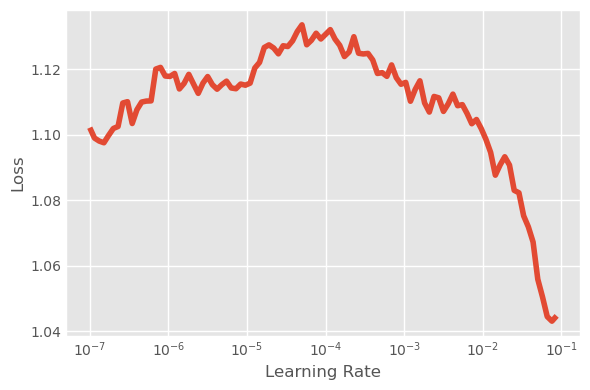

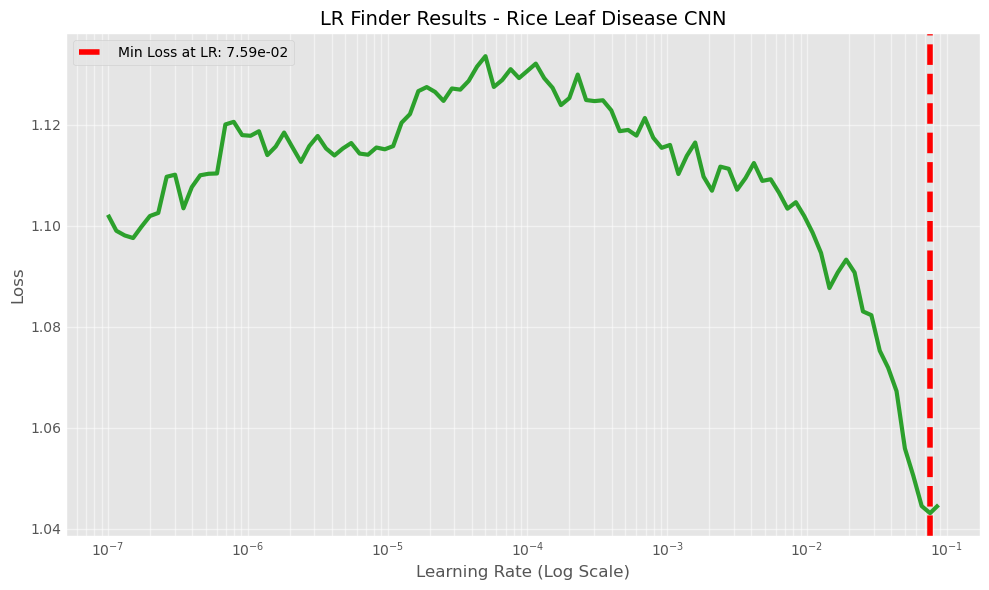

✅ Finished! Suggested LR is around 7.59e-02


In [110]:


os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
torch.set_num_threads(1)

print("📸 Taking a snapshot of the model and optimizer...")

initial_model_state = copy.deepcopy(sbs_cnn3.model.state_dict())
initial_optimizer_state = copy.deepcopy(sbs_cnn3.optimizer.state_dict())


for param_group in sbs_cnn3.optimizer.param_groups:
    param_group['lr'] = 1e-7

print("🚀 Starting LR Range Test...")


tracking, fig = sbs_cnn3.lr_range_test(
    train_loader,
    end_lr=0.1, 
    num_iter=100
)


sbs_cnn3.model.load_state_dict(initial_model_state)
sbs_cnn3.optimizer.load_state_dict(initial_optimizer_state)
print("⏪ Model and optimizer restored to original state!")


plt.figure(figsize=(10, 6))
plt.style.use('ggplot')

plt.plot(tracking['lr'], tracking['loss'], color='#2ca02c', linewidth=3)
plt.xscale("log") 

min_loss_idx = tracking['loss'].index(min(tracking['loss']))
best_lr_suggested = tracking['lr'][min_loss_idx]

plt.xlabel("Learning Rate (Log Scale)", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("LR Finder Results - Rice Leaf Disease CNN", fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.axvline(x=best_lr_suggested, color='red', linestyle='--', label=f'Min Loss at LR: {best_lr_suggested:.2e}')
plt.legend()

plt.tight_layout()
plt.show()

print(f"✅ Finished! Suggested LR is around {best_lr_suggested:.2e}")


<div dir=“lft”>

### 8.Updating Learning Rate

</div>

<div dir="rtl" align="right">

### به روز رسانی نرخ یادگیری
</div>



In [ ]:
import torch.optim as optim


suggested_lr = 7.59e-02

optimizer_cnn3 = optim.SGD(
    model_cnn3.parameters(), 
    lr=suggested_lr / 10, 
    momentum=0.9, 
    nesterov=True
)
sbs_cnn3.set_optimizer(optimizer_cnn3)

scheduler = optim.lr_scheduler.CyclicLR(
    optimizer_cnn3, 
    base_lr=suggested_lr / 10, 
    max_lr=suggested_lr,       
    step_size_up=len(train_loader), 
    mode='triangular2'
)
sbs_cnn3.set_lr_scheduler(scheduler)



### 9.Model Training

<div dir="rtl" align="right">

### آموزش مدل

In [112]:

sbs_cnn3.set_loaders(train_loader, test_loader)
sbs_cnn3.train(n_epochs=40)


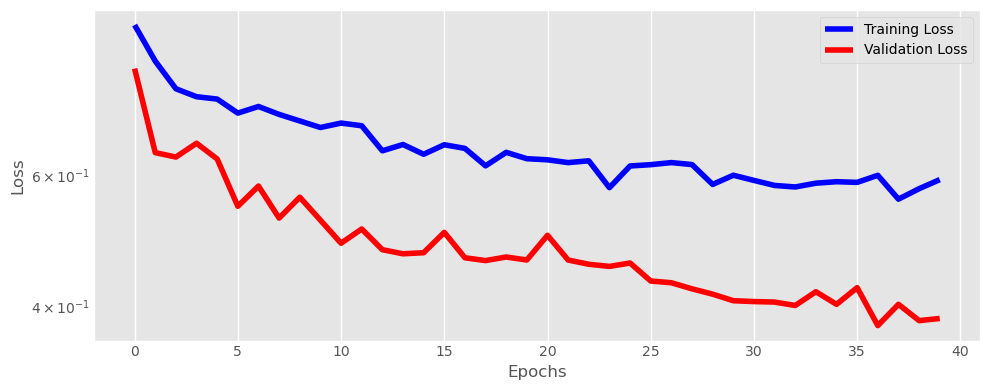

In [116]:
fig = sbs_cnn3.plot_losses()

# Analysis of Training and Validation Loss Plot (Right to Left)

## At epoch ~39:
- **Training Loss (blue):** ~0.6  
- **Validation Loss (red):** ~0.4  
- Validation loss is lower than training loss, possibly due to strong regularization or noise in training data.

## Epochs 30 to 38:
- Training loss fluctuates around 0.6 with some ups and downs.  
- Validation loss gradually decreases or stays around 0.4-0.45.

## Around epoch 20:
- Training loss shows peaks and fluctuations.  
- Validation loss trends down slowly.

## Between epochs 10 and 20:
- Training loss stable around 0.6-0.7.  
- Validation loss steadily decreases from ~0.55 to ~0.45.

## Epochs 0 to 10:
- Both losses drop sharply indicating fast initial learning.  
- Training loss falls from ~1.0 to ~0.7.  
- Validation loss drops from ~0.8 to ~0.5.

---

---
<div dir="rtl" align="right">

# فارسی:

- خط آبی: خطای آموزش  
- خط قرمز: خطای اعتبارسنجی  
- در ابتدا (سمت چپ نمودار)، هر دو خطا به سرعت کاهش می‌یابند (یادگیری سریع).  
- خطای اعتبارسنجی به کاهش خود ادامه می‌دهد ولی خطای آموزش ثابت و نوسانی است.  
- در اپوک‌های آخر، خطای آموزش بیشتر از اعتبارسنجی است که ممکن است به منظم‌سازی یا نویز مربوط باشد.  
- مدل به خوبی روی داده‌های اعتبارسنجی عمل کرده و تعمیم خوبی دارد.


In [117]:

train_results = StepByStep.loader_apply(train_loader, sbs_cnn3.correct).sum(axis=0)
test_results = StepByStep.loader_apply(test_loader, sbs_cnn3.correct).sum(axis=0)


train_correct, train_total = train_results[0], train_results[1]
test_correct, test_total = test_results[0], test_results[1]

train_acc = 100 * train_correct / train_total
test_acc = 100 * test_correct / test_total

print(f"📊 نتایج نهایی مدل برای بیماری‌های برنج:")
print(f"{'-'*40}")
print(f"✅ آموزش (Train): {train_correct:g}/{train_total:g} درست | دقت: {train_acc:.2f}%")
print(f"🎯 تست (Test):    {test_correct:g}/{test_total:g} درست | دقت: {test_acc:.2f}%")
print(f"{'-'*40}")


📊 نتایج نهایی مدل برای بیماری‌های برنج:
----------------------------------------
✅ آموزش (Train): 720/887 درست | دقت: 81.17%
🎯 تست (Test):    185/224 درست | دقت: 82.59%
----------------------------------------
